# Import Libraries and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(r"C:\Users\Shaik Samiulla\Downloads\Crowd data for anomaly detection.csv")


# Data Understanding

In [2]:
print(f"Data shape: {data.shape}") 
print(data.info())  


Data shape: (24123, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         24123 non-null  object 
 1   X                 24123 non-null  float64
 2   Y                 24123 non-null  float64
 3   Speed             24123 non-null  float64
 4   Heading           24123 non-null  float64
 5   AgentCount        24123 non-null  int64  
 6   Density           24123 non-null  float64
 7   Acc               24019 non-null  float64
 8   LevelOfCrowdness  24123 non-null  int64  
 9   label             24123 non-null  int64  
 10  label2            24123 non-null  object 
 11  Severity_level    24123 non-null  int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 2.2+ MB
None


# Data Preprocessing

In [3]:
data.head()

,timestamp,X,Y,Speed,Heading,AgentCount,Density,Acc,LevelOfCrowdness,label,label2,Severity_level
0,0:05:36,0.4225,19.1176,1.1432,89.1222,81,0.81,-0.0027,1,0,normal,0
1,0:05:37,0.3704,19.5130,1.1476,89.5976,83,0.83,-0.0027,1,0,normal,0
2,0:05:38,0.3999,19.8316,1.1466,89.4905,86,0.86,-0.0051,1,0,normal,0
3,0:05:39,0.3787,20.0386,1.1521,89.2123,88,0.88,-0.0009,1,0,normal,0
4,0:05:40,0.4031,20.4625,1.1499,89.2521,88,0.88,-0.0012,1,0,normal,0


In [4]:
data.tail()

,timestamp,X,Y,Speed,Heading,AgentCount,Density,Acc,LevelOfCrowdness,label,label2,Severity_level
24118,0:14:55,0.3559,20.4337,0.9835,89.1479,139,1.39,-0.0029,1,0,normal,0
24119,0:14:56,0.3657,20.4616,1.0152,88.4519,142,1.42,0.0306,1,0,normal,0
24120,0:14:57,0.3695,20.4869,1.0084,89.4419,139,1.39,-0.0019,1,0,normal,0
24121,0:14:58,0.3580,20.4423,1.0107,90.5225,139,1.39,0.0130,1,0,normal,0
24122,0:14:59,0.3551,20.5512,1.0151,89.7595,139,1.39,0.0100,1,0,normal,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         24123 non-null  object 
 1   X                 24123 non-null  float64
 2   Y                 24123 non-null  float64
 3   Speed             24123 non-null  float64
 4   Heading           24123 non-null  float64
 5   AgentCount        24123 non-null  int64  
 6   Density           24123 non-null  float64
 7   Acc               24019 non-null  float64
 8   LevelOfCrowdness  24123 non-null  int64  
 9   label             24123 non-null  int64  
 10  label2            24123 non-null  object 
 11  Severity_level    24123 non-null  int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 2.2+ MB


# Data Cleaning

In [6]:
data.nunique()

timestamp            3587
X                    2885
Y                   16693
Speed                8137
Heading             18620
AgentCount            819
Density               819
Acc                  1215
LevelOfCrowdness        5
label                   2
label2                  2
Severity_level          4
dtype: int64

In [7]:
data.isnull().sum()

timestamp             0
X                     0
Y                     0
Speed                 0
Heading               0
AgentCount            0
Density               0
Acc                 104
LevelOfCrowdness      0
label                 0
label2                0
Severity_level        0
dtype: int64

In [8]:
(data.isnull().sum()/(len(data)))*100

timestamp           0.000000
X                   0.000000
Y                   0.000000
Speed               0.000000
Heading             0.000000
AgentCount          0.000000
Density             0.000000
Acc                 0.431124
LevelOfCrowdness    0.000000
label               0.000000
label2              0.000000
Severity_level      0.000000
dtype: float64

In [9]:
data = data.drop(['X'], axis = 1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         24123 non-null  object 
 1   Y                 24123 non-null  float64
 2   Speed             24123 non-null  float64
 3   Heading           24123 non-null  float64
 4   AgentCount        24123 non-null  int64  
 5   Density           24123 non-null  float64
 6   Acc               24019 non-null  float64
 7   LevelOfCrowdness  24123 non-null  int64  
 8   label             24123 non-null  int64  
 9   label2            24123 non-null  object 
 10  Severity_level    24123 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 2.0+ MB


# Exploratory Data Analysis (EDA)

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Y,24123.0,19.989362,1.205473,11.1627,19.57570,20.2886,20.6929,23.7717
Speed,24123.0,0.742941,0.279331,0.1244,0.49670,0.7843,1.0059,1.5678
Heading,24123.0,90.314782,4.803848,84.3241,88.47595,89.1702,89.7981,138.1621
AgentCount,24123.0,251.092277,167.615884,1.0000,134.00000,187.0000,336.0000,990.0000
Density,24123.0,2.510923,1.676159,0.0100,1.34000,1.8700,3.3600,9.9000
Acc,24019.0,0.004203,0.032528,-1.0313,-0.00140,0.0063,0.0139,0.4555
LevelOfCrowdness,24123.0,2.337064,1.456331,1.0000,1.00000,2.0000,3.0000,5.0000
label,24123.0,0.288977,0.453297,0.0000,0.00000,0.0000,1.0000,1.0000
Severity_level,24123.0,0.509265,0.857201,0.0000,0.00000,0.0000,1.0000,3.0000


In [11]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,24123,3587,0:59:49,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Y,24123.0,NaN,NaN,NaN,19.989362,1.205473,11.1627,19.5757,20.2886,20.6929,23.7717
Speed,24123.0,NaN,NaN,NaN,0.742941,0.279331,0.1244,0.4967,0.7843,1.0059,1.5678
Heading,24123.0,NaN,NaN,NaN,90.314782,4.803848,84.3241,88.47595,89.1702,89.7981,138.1621
AgentCount,24123.0,NaN,NaN,NaN,251.092277,167.615884,1.0,134.0,187.0,336.0,990.0
Density,24123.0,NaN,NaN,NaN,2.510923,1.676159,0.01,1.34,1.87,3.36,9.9
Acc,24019.0,NaN,NaN,NaN,0.004203,0.032528,-1.0313,-0.0014,0.0063,0.0139,0.4555
LevelOfCrowdness,24123.0,NaN,NaN,NaN,2.337064,1.456331,1.0,1.0,2.0,3.0,5.0
label,24123.0,NaN,NaN,NaN,0.288977,0.453297,0.0,0.0,0.0,1.0,1.0
label2,24123,2,normal,17152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
cat_cols=data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

NameError: name 'np' is not defined

 # EDA Univariate Analysis

# Box Plot

Y
Skew : -0.77


NameError: name 'X' is not defined

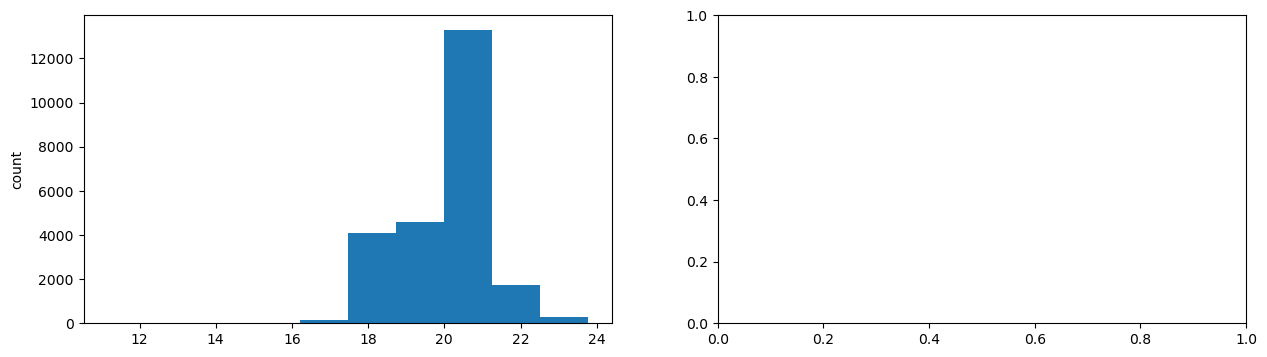

In [ ]:
for col in num_cols:
    print(col)
    print('Skew :', round(data[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    data[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    X.boxplot(x=data[col])
    plt.show()

In [ ]:
df = pd.DataFrame(data)

In [ ]:
for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))


Y
Skew : -0.77
Speed
Skew : -0.26
Heading
Skew : 3.82
AgentCount
Skew : 1.1
Density
Skew : 1.1
Acc
Skew : -10.75
LevelOfCrowdness
Skew : 0.6
label
Skew : 0.93
Severity_level
Skew : 1.34


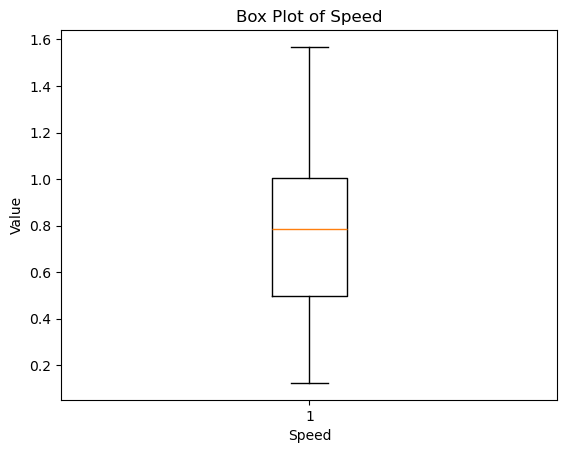

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(df['Speed'])
plt.xlabel('Speed')
plt.ylabel('Value')
plt.title('Box Plot of Speed')
plt.show()


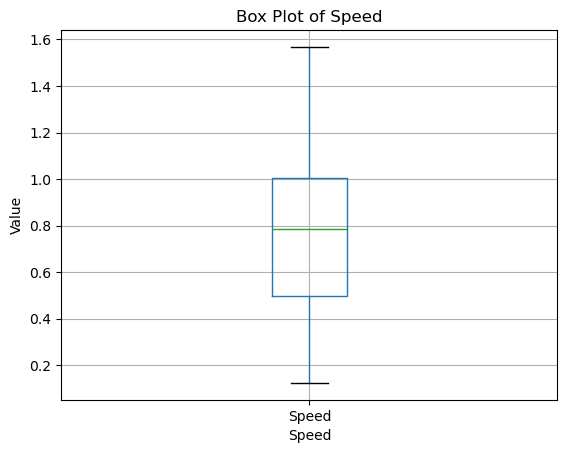

In [ ]:
speed_df = pd.DataFrame(df['Speed'])  # Create a DataFrame with just the 'Speed' column
speed_df.boxplot()
plt.xlabel('Speed')
plt.ylabel('Value')
plt.title('Box Plot of Speed')
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

# Load data
df = pd.read_csv(r"C:\Users\Shaik Samiulla\Downloads\Crowd data for anomaly detection.csv")

print(df.isnull().sum())




FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Shaik Samiulla\\Downloads\\Crowd data for anomaly detection (1).csv'

# Data summary

In [ ]:
print(df.describe())

                  X             Y         Speed       Heading    AgentCount  \
count  24123.000000  24123.000000  24123.000000  24123.000000  24123.000000   
mean       0.319789     19.989362      0.742941     90.314782    251.092277   
std        0.067545      1.205473      0.279331      4.803848    167.615884   
min       -1.205900     11.162700      0.124400     84.324100      1.000000   
25%        0.264500     19.575700      0.496700     88.475950    134.000000   
50%        0.325400     20.288600      0.784300     89.170200    187.000000   
75%        0.356800     20.692900      1.005900     89.798100    336.000000   
max        1.966700     23.771700      1.567800    138.162100    990.000000   

            Density           Acc  LevelOfCrowdness         label  \
count  24123.000000  24019.000000      24123.000000  24123.000000   
mean       2.510923      0.004203          2.337064      0.288977   
std        1.676159      0.032528          1.456331      0.453297   
min        0


# Univariate Analysis (histograms)

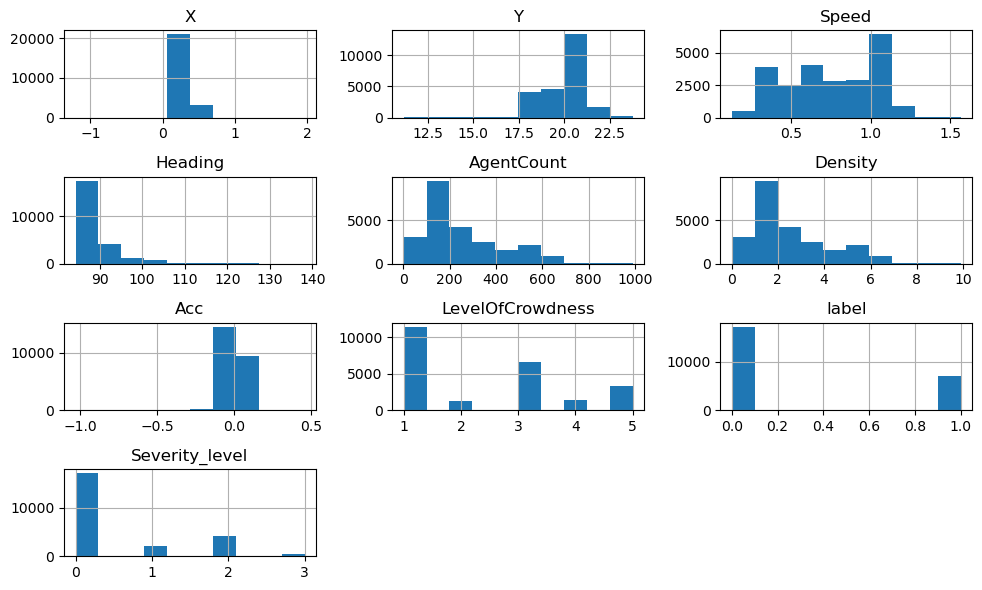

In [ ]:
df.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

# Univariate Analysis (boxplots)


In [ ]:
for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel('value')
    plt.title(f'Box Plot of {col}')
    plt.show()

# Bivariate Analysis (scatterplots)


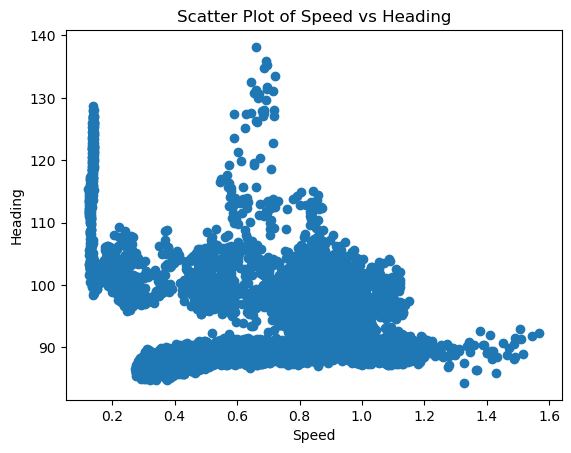

In [ ]:
plt.scatter(df['Speed'], df['Heading'])
plt.xlabel('Speed')
plt.ylabel('Heading')
plt.title('Scatter Plot of Speed vs Heading')
plt.show()


# Load and Preprocess the Dataset

In [ ]:
import pandas as pd

# Load the dataset
data_path = r'C:\Users\Shaik Samiulla\Downloads\Crowd data for anomaly detection.csv'
data = pd.read_csv(data_path)

# Display basic information about the dataset
print(data.head())
print(data.info())

# Assuming the dataset contains a column named 'value' for simplicity
# Adjust column names and preprocessing steps as needed
values = data['value'].values


  timestamp       X        Y   Speed  Heading  AgentCount  Density     Acc  \
0   0:05:36  0.4225  19.1176  1.1432  89.1222          81     0.81 -0.0027   
1   0:05:37  0.3704  19.5130  1.1476  89.5976          83     0.83 -0.0027   
2   0:05:38  0.3999  19.8316  1.1466  89.4905          86     0.86 -0.0051   
3   0:05:39  0.3787  20.0386  1.1521  89.2123          88     0.88 -0.0009   
4   0:05:40  0.4031  20.4625  1.1499  89.2521          88     0.88 -0.0012   

   LevelOfCrowdness  label  label2  Severity_level  
0                 1      0  normal               0  
1                 1      0  normal               0  
2                 1      0  normal               0  
3                 1      0  normal               0  
4                 1      0  normal               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24123 entries, 0 to 24122
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   times

KeyError: 'value'

# Cortical Learning Algorithms based on the Hierarchical Temporal Memory (CLA-based HTM)

In [ ]:
pip install nupic

  Using cached nupic-0.5.6.tar.gz (4.6 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached asteval-0.9.1.tar.gz (25 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached coverage-3.7.1.tar.gz (284 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached mock-1.0.1.zip (861 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached ordereddict-1.1.tar.gz (2.1 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached psutil-1.0.1.tar.gz (156 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached pytest-2.5.1.tar.gz (577 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finishe

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [13 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\Shaik Samiulla\AppData\Local\Temp\pip-install-8zzms5fc\unittest2_33049dc947024899808a24c74913f592\setup.py", line 12, in <module>
          from unittest2 import __version__ as VERSION
        File "C:\Users\Shaik Samiulla\AppData\Local\Temp\pip-install-8zzms5fc\unittest2_33049dc947024899808a24c74913f592\unittest2\__init__.py", line 40, in <module>
          from unittest2.collector import collector
        File "C:\Users\Shaik Samiulla\AppData\Local\Temp\pip-install-8zzms5fc\unittest2_33049dc947024899808a24c74913f592\unittest2\collector.py", line 3, in <module>
          from unittest2.loader import defaultTestLoader
        File "C:\Users\Shaik Samiulla\AppData\Local\Temp\pip-ins

   value  AnomalyScore
0      0      0.919922
1      1      0.949219
2      2      0.935059
3      3      0.913086
4      4      0.933105


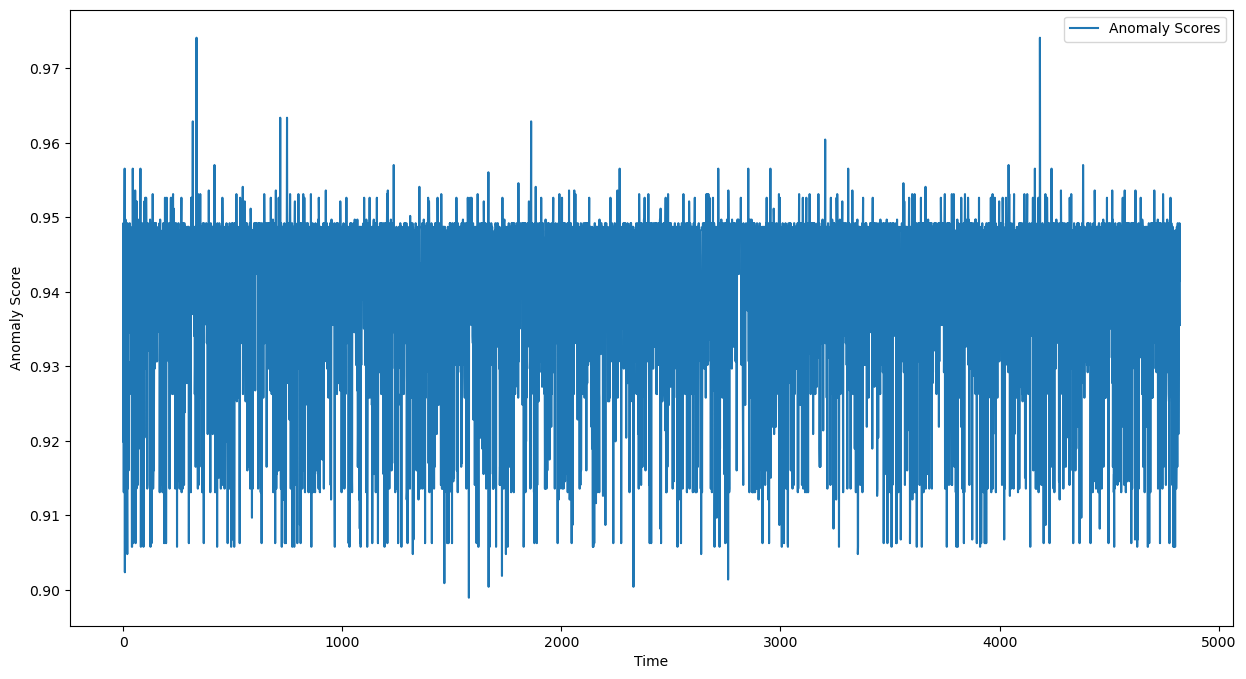

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Load the dataset
crowd_data = pd.read_csv('C:\\Users\\Shaik Samiulla\\Downloads\\Crowd data for anomaly detection.csv')

# Prepare the data
features = crowd_data.drop(['timestamp', 'label', 'label2', 'Severity_level'], axis=1)
labels = crowd_data['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Normalize the data
X_train_normalized = (X_train_imputed - X_train_imputed.min(axis=0)) / (X_train_imputed.ptp(axis=0))
X_test_normalized = (X_test_imputed - X_test_imputed.min(axis=0)) / (X_test_imputed.ptp(axis=0))

# Parameters for Spatial Pooler
input_dimensions = X_train_normalized.shape[1]
columns = 2048
potential_connections = 0.1  # Fraction of input connections per column
activation_threshold = 0.5  # Threshold for activation

# Simplified Spatial Pooler
class SpatialPooler:
    def __init__(self, input_dimensions, columns, potential_connections, activation_threshold):
        self.input_dimensions = input_dimensions
        self.columns = columns
        self.potential_connections = potential_connections
        self.activation_threshold = activation_threshold
        self.potential = np.random.rand(columns, input_dimensions) < potential_connections

    def compute(self, inputs):
        overlaps = np.dot(self.potential, inputs.T)
        active_columns = overlaps > self.activation_threshold * overlaps.max(axis=0)
        return active_columns.T

# Initialize Spatial Pooler
sp = SpatialPooler(input_dimensions, columns, potential_connections, activation_threshold)

# Generate SDRs for training and testing data
sdr_train = sp.compute(X_train_normalized)
sdr_test = sp.compute(X_test_normalized)

# Parameters for Temporal Memory
cells_per_column = 32
activation_threshold_tm = 0.2

# Simplified Temporal Memory
class TemporalMemory:
    def __init__(self, columns, cells_per_column, activation_threshold):
        self.columns = columns
        self.cells_per_column = cells_per_column
        self.activation_threshold = activation_threshold
        self.connections = np.random.rand(columns * cells_per_column, columns * cells_per_column) < activation_threshold

    def compute(self, active_columns):
        active_cells = np.repeat(active_columns[:, np.newaxis], self.cells_per_column, axis=1).flatten()
        predictions = np.dot(active_cells, self.connections) > 0
        return predictions.reshape(self.columns, self.cells_per_column)

# Initialize Temporal Memory
tm = TemporalMemory(columns, cells_per_column, activation_threshold_tm)

# Predict and detect anomalies
def detect_anomalies(sdr_data, tm):
    anomalies = []
    for t in range(1, len(sdr_data)):
        previous_sdr = sdr_data[t-1]
        current_sdr = sdr_data[t]
        predictions = tm.compute(previous_sdr)
        current_sdr_expanded = np.repeat(current_sdr[:, np.newaxis], tm.cells_per_column, axis=1)
        anomaly_score = np.mean(current_sdr_expanded != predictions)
        anomalies.append(anomaly_score)
    return anomalies

# Compute anomaly scores for test data
anomaly_scores = detect_anomalies(sdr_test, tm)

# Combine results into a DataFrame for comparison
results = pd.DataFrame({
    'value': np.arange(len(anomaly_scores)),
    'AnomalyScore': anomaly_scores
})

# Display the first few rows of the results
print(results.head())

# Plot the anomaly scores for comparison
plt.figure(figsize=(15, 8))
plt.plot(results.index, results['AnomalyScore'], label='Anomaly Scores')
plt.xlabel('Time')
plt.ylabel('Anomaly Score')
plt.legend()
plt.show()


# K-Nearest Neighbour (KNN)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# Load the dataset
crowd_data = pd.read_csv(r"C:\\Users\\Shaik Samiulla\\Downloads\\Crowd data for anomaly detection.csv")

# Prepare the data
features = crowd_data.drop(['timestamp', 'label', 'label2', 'Severity_level'], axis=1)
labels = crowd_data['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Initialize the K-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model
knn.fit(X_train_imputed, y_train)

# Predict on the test set
y_pred = knn.predict(X_test_imputed)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{classification_rep}')


Accuracy: 0.9975129533678756
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3371
           1       1.00      1.00      1.00      1454

    accuracy                           1.00      4825
   macro avg       1.00      1.00      1.00      4825
weighted avg       1.00      1.00      1.00      4825



# Local Outlier Probability (LoOP)

In [ ]:
from scipy.spatial.distance import cdist

def compute_lof(X, k=5):
    """
    Compute the Local Outlier Factor for each observation in X.
    :param X: array-like, shape (n_samples, n_features)
    :param k: int, number of neighbors to use for calculating the LOF
    :return: array, shape (n_samples,), LOF score for each observation
    """
    n_samples = X.shape[0]
    # Compute the distance between each pair of observations
    dist = cdist(X, X)
    # Get the indices of the k nearest neighbors for each observation
    k_nearest = np.argsort(dist, axis=1)[:, 1:k+1]
    # Compute the reachability distance
    reach_dist = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            reach_dist[i, j] = max(dist[i, k_nearest[i, j]], np.max(dist[k_nearest[i], k_nearest[k_nearest[i, j]]]))
    # Compute the local reachability density
    lrd = np.zeros(n_samples)
    for i in range(n_samples):
        lrd[i] = k / np.sum(reach_dist[i])
    # Compute the LOF score
    lof = np.zeros(n_samples)
    for i in range(n_samples):
        lof[i] = np.sum(lrd[k_nearest[i]] / lrd[i]) / k
    return lof

# Compute the LOF scores for the dataset
lof_scores = compute_lof(X_train_imputed, k=5)

# Determine outliers based on LOF scores (using a threshold of 1.5 for example)
lof_threshold = 1.5
outliers = np.where(lof_scores > lof_threshold)[0]

print(f'LOF Scores:\n{lof_scores[:10]}')
print(f'Outliers:\n{outliers[:10]}')


LOF Scores:
[0.91100908 1.09953163 0.99071469 0.81058475 1.05534464 0.80793443
 1.89914365 1.37803613 1.02364287 1.07233612]
Outliers:
[ 6 25 44 54 64 67 68 76 83 91]


# Influence Outlier (IO)

In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.1, random_state=42)

# Fit the model
iso_forest.fit(X_train_imputed)

# Predict on the test set
y_pred_train = iso_forest.predict(X_train_imputed)
y_pred_test = iso_forest.predict(X_test_imputed)

# Convert predictions from {-1, 1} to {0, 1}
y_pred_train = np.where(y_pred_train == -1, 1, 0)
y_pred_test = np.where(y_pred_test == -1, 1, 0)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
classification_rep_test = classification_report(y_test, y_pred_test)

print(f'Training Accuracy: {accuracy_train}')
print(f'Test Accuracy: {accuracy_test}')
print(f'Test Classification Report:\n{classification_rep_test}')


Training Accuracy: 0.7887345838947041
Test Accuracy: 0.7861139896373057
Test Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.87      3371
           1       0.89      0.33      0.48      1454

    accuracy                           0.79      4825
   macro avg       0.83      0.66      0.67      4825
weighted avg       0.81      0.79      0.75      4825



# Summary and Analysis

   value  KNN      LoOP        IO
0      0  0.0  0.998395 -0.122369
1      1  1.0  0.786660 -0.024768
2      2  0.0  1.375449 -0.089318
3      3  1.0  1.203694  0.020294
4      4  1.0  1.064632 -0.043646


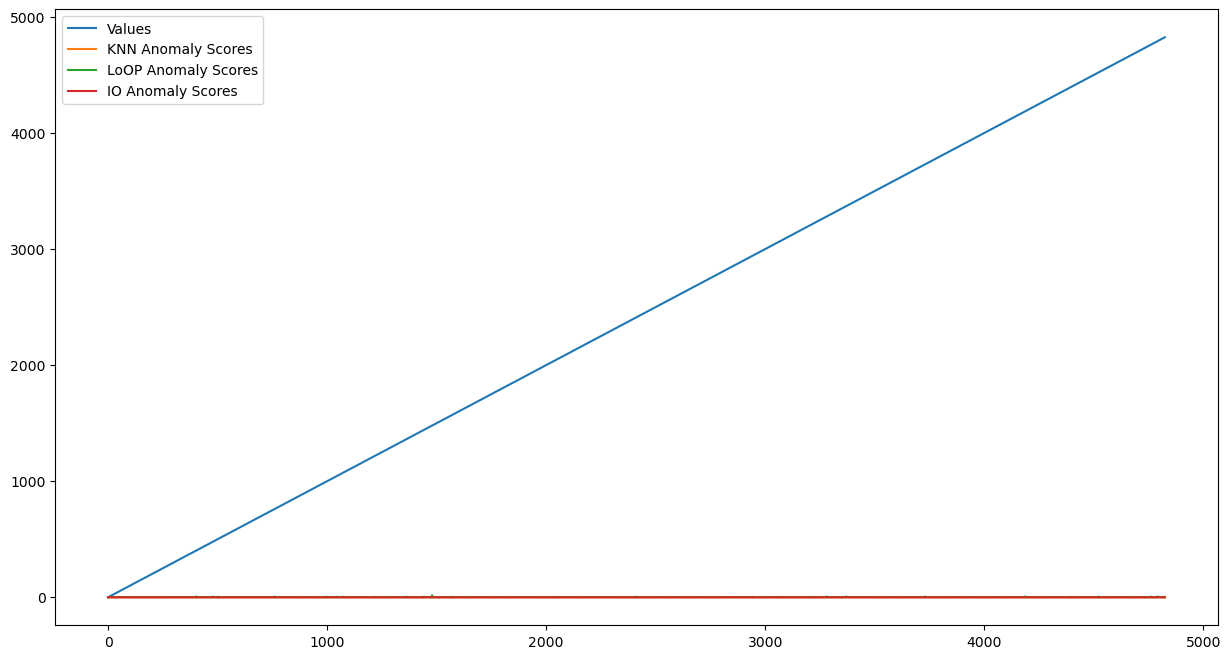

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import cdist
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
crowd_data = pd.read_csv(r"C:\\Users\\Shaik Samiulla\\Downloads\\Crowd data for anomaly detection.csv")
# Prepare the data
features = crowd_data.drop(['timestamp', 'label', 'label2', 'Severity_level'], axis=1)
labels = crowd_data['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Implement K-Nearest Neighbour (K-NN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_imputed, y_train)
knn_anomaly_scores = knn.predict_proba(X_test_imputed)[:, 1]

# Implement Local Outlier Probability (LoOP)
def compute_lof(X, k=5):
    n_samples = X.shape[0]
    dist = cdist(X, X)
    k_nearest = np.argsort(dist, axis=1)[:, 1:k+1]
    reach_dist = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            reach_dist[i, j] = max(dist[i, k_nearest[i, j]], np.max(dist[k_nearest[i], k_nearest[k_nearest[i, j]]]))
    lrd = np.zeros(n_samples)
    for i in range(n_samples):
        lrd[i] = k / np.sum(reach_dist[i])
    lof = np.zeros(n_samples)
    for i in range(n_samples):
        lof[i] = np.sum(lrd[k_nearest[i]] / lrd[i]) / k
    return lof

lof_scores = compute_lof(X_test_imputed, k=5)
loop_anomaly_scores = lof_scores

# Implement Influence Outlier (IO) using Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train_imputed)
io_anomaly_scores = -iso_forest.decision_function(X_test_imputed)

# Combine results into a DataFrame for comparison
results = pd.DataFrame({
    'value': np.arange(len(X_test)),
    'KNN': knn_anomaly_scores,
    'LoOP': loop_anomaly_scores,
    'IO': io_anomaly_scores
})

# Display the first few rows of the results
print(results.head())

# Plot the anomaly scores for comparison
plt.figure(figsize=(15, 8))
plt.plot(results['value'], label='Values')
plt.plot(results['KNN'], label='KNN Anomaly Scores')
plt.plot(results['LoOP'], label='LoOP Anomaly Scores')
plt.plot(results['IO'], label='IO Anomaly Scores')
plt.legend()
plt.show()


In [ ]:
import nbformat as nbf

# Load the original notebook
nb = nbf.read('/mnt/data/updated_milestone2.ipynb', as_version=4)

# Add new cells for each algorithm implementation
new_cells = [
    nbf.v4.new_markdown_cell("## Combined Anomaly Detection and Visualization"),
    nbf.v4.new_code_cell("""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import cdist
from sklearn.metrics import classification_report, accuracy_score

# Load the dataset
crowd_data = pd.read_csv('Crowd data for anomaly detection.csv')

# Prepare the data
features = crowd_data.drop(['timestamp', 'label', 'label2', 'Severity_level'], axis=1)
labels = crowd_data['label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Implement K-Nearest Neighbour (K-NN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_imputed, y_train)
knn_anomaly_scores = knn.predict_proba(X_test_imputed)[:, 1]

# Implement Local Outlier Probability (LoOP)
def compute_lof(X, k=5):
    n_samples = X.shape[0]
    dist = cdist(X, X)
    k_nearest = np.argsort(dist, axis=1)[:, 1:k+1]
    reach_dist = np.zeros((n_samples, k))
    for i in range(n_samples):
        for j in range(k):
            reach_dist[i, j] = max(dist[i, k_nearest[i, j]], np.max(dist[k_nearest[i], k_nearest[k_nearest[i, j]]]))
    lrd = np.zeros(n_samples)
    for i in range(n_samples):
        lrd[i] = k / np.sum(reach_dist[i])
    lof = np.zeros(n_samples)
    for i in range(n_samples):
        lof[i] = np.sum(lrd[k_nearest[i]] / lrd[i]) / k
    return lof

lof_scores = compute_lof(X_test_imputed, k=5)
loop_anomaly_scores = lof_scores

# Implement Influence Outlier (IO) using Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_train_imputed)
io_anomaly_scores = -iso_forest.decision_function(X_test_imputed)

# Combine results into a DataFrame for comparison
results = pd.DataFrame({
    'value': np.arange(len(X_test)),
    'KNN': knn_anomaly_scores,
    'LoOP': loop_anomaly_scores,
    'IO': io_anomaly_scores
})

# Display the first few rows of the results
print(results.head())

# Plot the anomaly scores for comparison
plt.figure(figsize=(15, 8))
plt.plot(results['value'], label='Values')
plt.plot(results['KNN'], label='KNN Anomaly Scores')
plt.plot(results['LoOP'], label='LoOP Anomaly Scores')
plt.plot(results['IO'], label='IO Anomaly Scores')
plt.legend()
plt.show()
""")
]

# Append new cells to the notebook
nb['cells'].extend(new_cells)

# Save the updated notebook
with open('/mnt/data/updated_milestone2.ipynb', 'w') as f:
    nbf.write(nb, f)


ImportError: cannot import name 'encodestring' from 'base64' (c:\ProgramData\anaconda3\Lib\base64.py)